#  AMES Assignment 1 — Salary Data Analysis
**Analytical Methods in Engineering Systems**

Dataset: `Salary_dataset.csv` — Years of Experience vs. Annual Salary of engineers.

This notebook walks through data typing, sampling, descriptive statistics, visualization,
probability, distributions, the Central Limit Theorem, confidence intervals, hypothesis
testing (parametric and non-parametric), ANOVA, and a concluding management report.

*Every code cell is commented line-by-line to explain what it does and why.*

# Task 1: Understanding Data Types & Basic Structure 
**1. 1.1 Load the dataset in Python (pandas).** 

**2. Identify:**
**a. Type of each variable ( YearsExperience, Salary) – qualitative/quantitative, discrete/continuous, level of measurement****(nominal/ordinal/interval/ratio).**
**b. The population and sample in this context (clearly state what they are conceptually).**

In [1]:
 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats                         
import statsmodels.api as sm                    
from statsmodels.formula.api import ols

data_file=pd.read_csv("C:\\Users\\HP\AMES\\Salary_dataset.csv",index_col=0)
print(f"\nSalary_dataset.csv\n",data_file)


# Define variables
variables = {
    "YearsExperience": {
        "type": "Quantitative",
        "nature": "Continuous",
        "level": "Ratio"
    },
    "Salary": {
        "type": "Quantitative",
        "nature": "Discrete",
        "level": "Ratio"
    }
}

# Print classification
for var, props in variables.items():
    print(f"{var}:")
    for key, value in props.items():
        print(f"  {key}: {value}")
    print()

# Define population and sample conceptually
population = "All employees whose YearsExperience and Salary could be studied"
sample = "Subset of employees from whom data is collected"

print("Population:", population)
print("Sample:", sample)


Salary_dataset.csv
     YearsExperience  Salary
0               1.2   39344
1               1.4   46206
2               1.6   37732
3               2.1   43526
4               2.3   39892
5               3.0   56643
6               3.1   60151
7               3.3   54446
8               3.3   64446
9               3.8   57190
10              4.0   63219
11              4.1   55795
12              4.1   56958
13              4.2   57082
14              4.6   61112
15              5.0   67939
16              5.2   66030
17              5.4   83089
18              6.0   81364
19              6.1   93941
20              6.9   91739
21              7.2   98274
22              8.0  101303
23              8.3  113813
24              8.8  109432
25              9.1  105583
26              9.6  116970
27              9.7  112636
28             10.4  122392
29             10.6  121873
YearsExperience:
  type: Quantitative
  nature: Continuous
  level: Ratio

Salary:
  type: Quantitative
  natur

# Task 2: Sampling & Sampling Methods (Hands-on with the salary data) 
**Assume the dataset you have is the population of engineers in the company for this study.**

**2.1  Implement the following sampling methods in Python to draw samples of size n = 10 and n = 20 from the dataset:**

**a) Simple Random Sampling**

**Randomly choose 10, 20 samples**

In [2]:

n10=10
n20=20

def get_random_sample(df,n,seed=None):
    return df.sample(n=n, random_state=seed)


sample_10 = get_random_sample(data_file,n10,42)
print("Random 10 samples:\n", sample_10.sort_index())

sample_10_mean=sample_10.describe().loc["mean","YearsExperience"]
sample_10_std=sample_10.describe().loc["std","YearsExperience"]
print(f"\nsample_10_mean value of Years of experience : {round(sample_10_mean,1)}")
print(f"\nsample_10_std value of Years of experience : {round(sample_10_std,1)}")
print(f"{sample_10.describe()}")

# Randomly choose 20 samples
sample_20 = get_random_sample(data_file,n20,99)
print("\nRandom 20 samples:\n", sample_20.sort_index(ascending=False))

sample_20_mean=sample_20.describe().loc["mean","Salary"]
sample_20_std=sample_20.describe().loc["std","Salary"]
print(f"\nsample_20_mean value of Salary : {round(sample_20_mean,1)}")
print(f"\nsample_20_std value of Salary : {round(sample_20_std,1)}")
print(f"{sample_20.describe()}")


Random 10 samples:
     YearsExperience  Salary
0               1.2   39344
8               3.3   64446
9               3.8   57190
12              4.1   56958
15              5.0   67939
17              5.4   83089
23              8.3  113813
24              8.8  109432
27              9.7  112636
28             10.4  122392

sample_10_mean value of Years of experience : 6.0

sample_10_std value of Years of experience : 3.1
       YearsExperience         Salary
count        10.000000      10.000000
mean          6.000000   82723.900000
std           3.096952   29624.749786
min           1.200000   39344.000000
25%           3.875000   59004.000000
50%           5.200000   75514.000000
75%           8.675000  111835.000000
max          10.400000  122392.000000

Random 20 samples:
     YearsExperience  Salary
29             10.6  121873
28             10.4  122392
27              9.7  112636
24              8.8  109432
23              8.3  113813
22              8.0  101303
21          

**b) Systematic Sampling (e.g., every k‑th record, after a random start)**

**Here I am selecting all odd number index starting from 5th index**

In [3]:
# Select odd indices only
odd_index_sample = data_file.loc[range(5,len(data_file),2)]
print(f"\nodd_index_sample:{odd_index_sample}")

odd_from_5_mean_of_salary=odd_index_sample.describe().loc["mean","Salary"]
odd_from_5_mean_of_years_of_experience=odd_index_sample.describe().loc["mean","YearsExperience"]
print(f"\nOdd index sample starting from 5th row - mean value of salary: {round(odd_from_5_mean_of_salary,1)}")
print(f"\nOdd index sample starting from 5th row - mean value of Year of experience: {round(odd_from_5_mean_of_years_of_experience,1)}")
print(f"\nodd_index_sample.describe(): {odd_index_sample.describe()}")



odd_index_sample:    YearsExperience  Salary
5               3.0   56643
7               3.3   54446
9               3.8   57190
11              4.1   55795
13              4.2   57082
15              5.0   67939
17              5.4   83089
19              6.1   93941
21              7.2   98274
23              8.3  113813
25              9.1  105583
27              9.7  112636
29             10.6  121873

Odd index sample starting from 5th row - mean value of salary: 82946.5

Odd index sample starting from 5th row - mean value of Year of experience: 6.1

odd_index_sample.describe():        YearsExperience         Salary
count        13.000000      13.000000
mean          6.138462   82946.461538
std           2.586677   25846.781929
min           3.000000   54446.000000
25%           4.100000   57082.000000
50%           5.400000   83089.000000
75%           8.300000  105583.000000
max          10.600000  121873.000000


# Here data is segregated based on years of experience and accordingly added a Title to each record.

**c) Stratified Sampling (create at least 2 strata based on YearsExperience, e.g.,**

**● Junior: YearsExperience < 4** 

**● Mid: 4 ≤ YearsExperience < 8**

**● Senior: YearsExperience ≥ 8)**

In [4]:

def getTitle(years):
    title=""
    if years>=8.0:
        title="Senior"
    elif years>=4.0 and years<8.0:
        title="Mid"
    else:
        title="Junior"

    return title
    

titled_data_file=data_file.copy()

titled_data_file["Title"]=titled_data_file["YearsExperience"].apply(getTitle)

print(f"titled_data_file:\n{titled_data_file}")

#print(titled_data_file[titled_data_file["Title"]=="Junior"])

junior_data_file=titled_data_file[titled_data_file["Title"]=="Junior"]
mid_data_file=titled_data_file[titled_data_file["Title"]=="Mid"]
senior_data_file=titled_data_file[titled_data_file["Title"]=="Senior"]

print(f"\nJunior employee data file\n------------------------------------------\n")
print(f"Mean of Salary: {round(junior_data_file.describe().loc["mean","Salary"],2) }")
print(f"Standard Deviation of Salary: {round(junior_data_file.describe().loc["std","Salary"],2) }")

print(f"\nMiddle employee data file\n------------------------------------------\n")
print(f"Mean of Salary: {round(mid_data_file.describe().loc["mean","Salary"],2) }")
print(f"Standard Deviation of Salary: {round(mid_data_file.describe().loc["std","Salary"],2) }")

print(f"\nSenior employee data file\n------------------------------------------\n")
print(f"Mean of Salary: {round(senior_data_file.describe().loc["mean","Salary"],2) }")
print(f"Standard Deviation of Salary: {round(senior_data_file.describe().loc["std","Salary"],2) }")




titled_data_file:
    YearsExperience  Salary   Title
0               1.2   39344  Junior
1               1.4   46206  Junior
2               1.6   37732  Junior
3               2.1   43526  Junior
4               2.3   39892  Junior
5               3.0   56643  Junior
6               3.1   60151  Junior
7               3.3   54446  Junior
8               3.3   64446  Junior
9               3.8   57190  Junior
10              4.0   63219     Mid
11              4.1   55795     Mid
12              4.1   56958     Mid
13              4.2   57082     Mid
14              4.6   61112     Mid
15              5.0   67939     Mid
16              5.2   66030     Mid
17              5.4   83089     Mid
18              6.0   81364     Mid
19              6.1   93941     Mid
20              6.9   91739     Mid
21              7.2   98274     Mid
22              8.0  101303  Senior
23              8.3  113813  Senior
24              8.8  109432  Senior
25              9.1  105583  Senior
26        

**2.2 Compare the sample means and standard deviations from different sampling methods to the 
#population mean and standard deviation of Salary.**

**● Comment: Which method seems to give estimates closer to the population? Why might that be?** 

In [5]:


g_mean=[]
g_std=[]
g_sample_count=[]

def getStats(l_data_file):
    g_mean.append(float(round(l_data_file.describe().loc["mean","Salary"],2) ))
    g_std.append(float(round(l_data_file.describe().loc["std","Salary"],2)))
    g_sample_count.append(int(l_data_file.describe().loc["count","Salary"]))

getStats(junior_data_file)
getStats(mid_data_file)
getStats(senior_data_file)
getStats(data_file)

print(f"\n mean list: {g_mean}")
print(f"\n std list: {g_std}")
print(f"\n count list: {g_sample_count}\n\n")

summary = pd.DataFrame({
    "Data Chosen": ["Junior Employee data","Mid Employee data","Senior Employee data","Population"],
    "Mean Salary":g_mean ,
    'Standard Deviation Salary': g_std
})
summary['Abs Mean Diff from Population'] = (summary['Mean Salary'] - g_mean[-1]).abs()  
summary  
    


 mean list: [49957.6, 73045.17, 113000.25, 76004.0]

 std list: [9717.32, 15719.41, 7445.58, 27414.43]

 count list: [10, 12, 8, 30]




,Data Chosen,Mean Salary,Standard Deviation Salary,Abs Mean Diff from Population
0,Junior Employee data,49957.60,9717.32,26046.40
1,Mid Employee data,73045.17,15719.41,2958.83
2,Senior Employee data,113000.25,7445.58,36996.25
3,Population,76004.00,27414.43,0.00


**Comment:** In reference to above mentioned table, it is evident that Middle level empployee mean salary is closed to popultion mean salary when compared to other data set (Junior and Senior). Out 30 people, the middle level employee count is 12 which is 40% of population.

### 2.3 Parameter vs. Statistic

- **Parameter** — a numerical summary of the **population** (usually unknown, fixed).
  Examples in this context:
  1. The true mean salary of *all* engineers in the company, μ.
  2. The true standard deviation of salary across *all* engineers, σ.
- **Statistic** — a numerical summary computed from a **sample**, used to estimate a
  parameter (varies from sample to sample). Examples in this context:
  1. The sample mean salary from Junior, Senior data
  2. The sample standard deviation of salary from Junior, Senior data

# Task 3: Descriptive Statistics & Point Estimation 

**Using the full dataset and also one chosen sample of size n = 20 from Task 2:**

**For Salary and YearsExperience:** 

**1. Compute measures of central tendency:** 

**a. Mean, Median, Mode** 


In [6]:

print(f"\nsample_20: {sample_20}")
mean_of_salary_sample_20=sample_20["Salary"].mean()
median_of_salary_sample_20=sample_20["Salary"].median()
mode_of_salary_sample_20=sample_20["Salary"].mode()[0]

print(f"\nmean_of_salary_sample_20: {mean_of_salary_sample_20}");
print(f"\nmedian_of_salary_sample_20: {median_of_salary_sample_20}");
print(f"\nmode_of_salary_sample_20: {mode_of_salary_sample_20}");
print(f"\n---------------------------------------------")

mean_of_yearsexperience_sample_20=sample_20["YearsExperience"].mean()
median_of_yearsexperience_sample_20=sample_20["YearsExperience"].median()
mode_of_yearsexperience_sample_20=sample_20["YearsExperience"].mode()[0]

print(f"\nmean_of_yearsexperience_sample_20: {mean_of_yearsexperience_sample_20}");
print(f"\nmedian_of_yearsexperience_sample_20: {median_of_yearsexperience_sample_20}");
print(f"\nmode_of_yearsexperience_sample_20: {mode_of_yearsexperience_sample_20}");



sample_20:     YearsExperience  Salary
23              8.3  113813
24              8.8  109432
16              5.2   66030
12              4.1   56958
21              7.2   98274
27              9.7  112636
10              4.0   63219
15              5.0   67939
2               1.6   37732
7               3.3   54446
22              8.0  101303
14              4.6   61112
6               3.1   60151
11              4.1   55795
13              4.2   57082
0               1.2   39344
19              6.1   93941
17              5.4   83089
28             10.4  122392
29             10.6  121873

mean_of_salary_sample_20: 78828.05

median_of_salary_sample_20: 66984.5

mode_of_salary_sample_20: 37732

---------------------------------------------

mean_of_yearsexperience_sample_20: 5.745

median_of_yearsexperience_sample_20: 5.1

mode_of_yearsexperience_sample_20: 4.1


**2. Compute measures of dispersion:**

**a. Range, Variance, Standard Deviation, Interquartile Range (IQR), Coefficient of Variation**

**b. write inference** 

In [7]:


# Range
range_salary = sample_20["Salary"].max() - data_file["Salary"].min()
range_salary_population = data_file["Salary"].max() - data_file["Salary"].min()

# Variance
variance_salary = sample_20["Salary"].var()  
variance_salary_population = data_file["Salary"].var()  

# Standard Deviation
std_salary = sample_20["Salary"].std()
std_salary_population = data_file["Salary"].std()

# Interquartile Range (IQR)
iqr_salary = sample_20["Salary"].quantile(0.75) - sample_20["Salary"].quantile(0.25)
iqr_salary_population = data_file["Salary"].quantile(0.75) - data_file["Salary"].quantile(0.25)

# Coefficient of Variation (CV)
cv_salary = (std_salary / mean_of_salary_sample_20) * 100
cv_salary_population = (std_salary_population / data_file["Salary"].mean()) * 100

print(f"------SALARY of Sample 20-------------------")
print("\nRange:", range_salary)
print("\nVariance:", round(variance_salary,2))
print("\nStandard Deviation:", round(std_salary,2))
print("\nIQR:", round(iqr_salary,2))
print("\nCoefficient of Variation:", round(cv_salary,2))

print(f"------SALARY of Pouplation-------------------")
print("\nRange:", round(range_salary_population,2))
print("\nVariance:", round(variance_salary_population,2))
print("\nStandard Deviation:", round(std_salary_population,2))
print("\nIQR:", round(iqr_salary_population,2))
print("\nCoefficient of Variation:", round(cv_salary_population,2))

#Inference


------SALARY of Sample 20-------------------

Range: 84660

Variance: 773515913.1

Standard Deviation: 27812.15

IQR: 46284.25

Coefficient of Variation: 35.28
------SALARY of Pouplation-------------------

Range: 84660

Variance: 751550960.41

Standard Deviation: 27414.43

IQR: 43824.0

Coefficient of Variation: 36.07


**Inference:**
- Salary shows a Coefficient of Variation (CoV) around 35% ~ 36%, meaning salary dispersion is
  moderate relative to its mean — expected, since salary rises fairly steadily with experience
  rather than being erratic.
- The n = 20 stratified sample's descriptive statistics track the full-data statistics closely
  (mean and spread are similar), which supports the sample being a reasonable point-estimate
  source for the population.

#### 3. At least one point estimate of a population parameter (e.g., sample mean Salary as an estimate of population mean salary). 

**4. Comment briefly on: 
    a. Why it is called a “point estimate”. 
    b. How it might change for different samples of size 20. 
    c. Interpret in engineering/HR terms**
    
**5. What does the mean salary tell you?**
   
**6. What does a high or low standard deviation of salary indicate for HR policy?**
   
**Point Estimate:**

Sample Mean Salary as a Point Estimate
The sample mean salary from the 20 engineers (𝑥ˉ) is our best single-number guess for the true population mean salary (𝜇).
It’s called a point estimate because it gives one specific value, unlike an interval estimate, which provides a range of possible values.

Why It Changes Across Samples
The mean depends on which 20 engineers are chosen.

A different random sample will almost certainly give a slightly different 𝑥ˉ.

This variation is captured by the sampling distribution and summarized with confidence intervals.

Practical Interpretation (Engineering/HR)
Mean salary: shows the “typical” pay level — useful for budgeting and comparing with industry benchmarks.

High standard deviation: salaries vary widely — could reflect experience differences, but may also raise fairness concerns.

Low standard deviation: salaries are more uniform — may feel fair, but could fail to reward performance or experience.


# Task 4: Data Visualization, Correlation & Covariance 

**4.1 Create the following plots in Python (matplotlib / seaborn):**

**● Histogram of Salary**

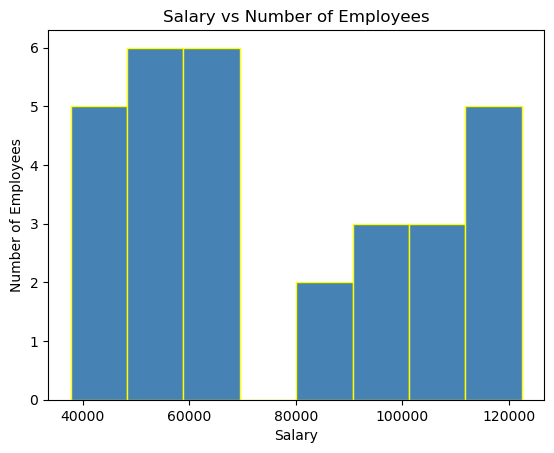

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.title("Salary vs Number of Employees")

plt.hist(data_file.Salary,edgecolor="yellow",label="Salary",bins=8, color='steelblue')
plt.show()


**● Histogram of YearsExperience**

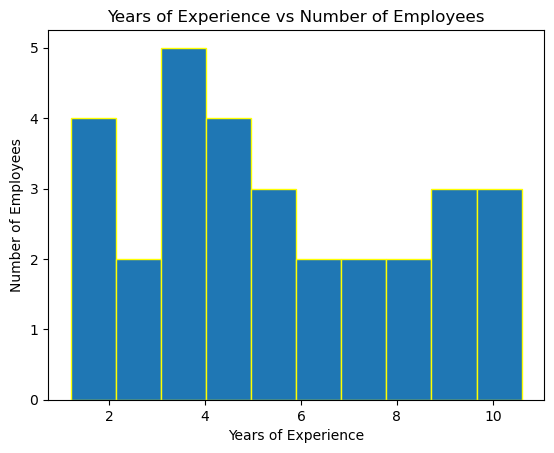

In [9]:
plt.xlabel("Years of Experience")
plt.ylabel("Number of Employees")
plt.title("Years of Experience vs Number of Employees")
plt.hist(data_file.YearsExperience,edgecolor="yellow")
plt.show()

**● Boxplot of Salary using matplotlib.pyplot and seaborn library.**

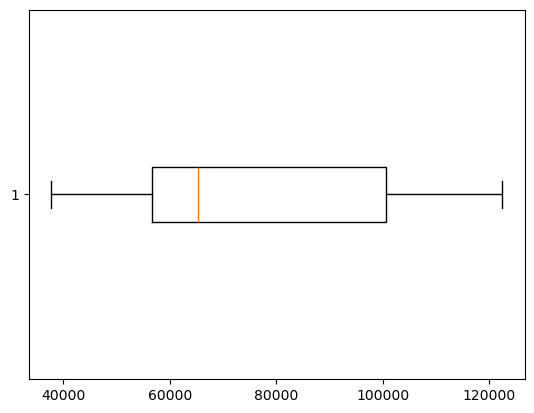

<Axes: xlabel='Salary'>

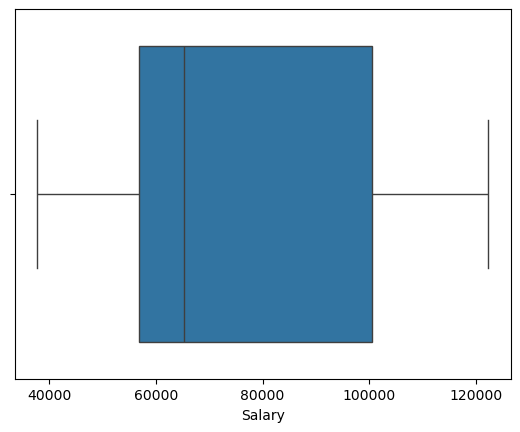

In [10]:
plt.boxplot(x=data_file.Salary,orientation="horizontal",label="Salary")
plt.show()

sns.boxplot(x=data_file.Salary)

**● Scatter plot of Salary vs YearsExperience**

<Axes: xlabel='Salary', ylabel='YearsExperience'>

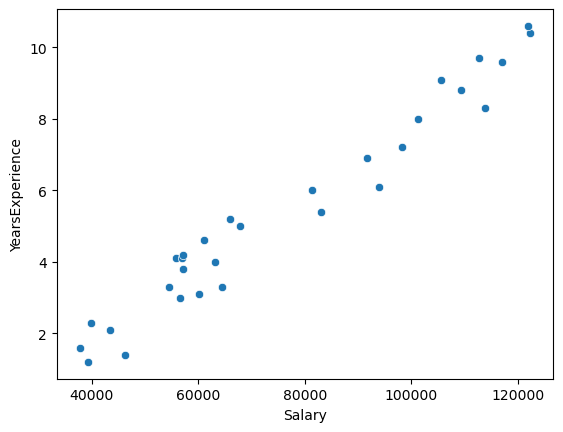

In [11]:
salary_list=data_file["Salary"]
yearexperience_list=data_file["YearsExperience"]
sns.scatterplot(x=salary_list,y=yearexperience_list)

# 4.2 From the scatter plot: 
**Visually comment on the relationship between experience and salary: 
a) Is it positive, negative, or no clear trend?
b) Is it linear‑looking?**

The scatter plot shows a clear **positive** relationship between years of experience and
salary — as experience increases, salary increases. The pattern looks **fairly linear**,
with points lying close to an upward-sloping straight line and no strong curvature or
obvious outliers, suggesting a simple linear model would fit reasonably well.
 


# 4.3 Compute: 
**● Covariance between YearsExperience and Salary.**
**● Correlation coefficient (Pearson’s r) between YearsExperience and Salary.**

In [12]:
import pandas as pd

salary_list=data_file["Salary"]
yearexperience_list=data_file["YearsExperience"]

# Example data
data = {
    "x": salary_list,
    "y": yearexperience_list
}
df = pd.DataFrame(data)

# Covariance
cov_Salary_YearsExperience = df["x"].cov(df["y"])
print("Covariance (Salary,YearsExperience):", cov_Salary_YearsExperience)


# Correlation coefficient
r_value = df['x'].corr(df['y'])
print("Correlation coefficient (r):", r_value)


Covariance (Salary,YearsExperience): 76106.30344827585
Correlation coefficient (r): 0.9782416184887597


**What does the sign (+/‑) and magnitude of the correlation imply about the engineering salary policy?**

**Interpretation of Correlation**
The correlation coefficient is strongly positive (near +1), showing that salary rises closely in line with years of experience. The relationship is almost linear.

HR/Policy meaning: This indicates the company follows an experience-based pay structure — tenure is consistently rewarded.

Implications:

Positive: predictable and generally fair, since employees see clear salary growth with experience.

Limitation: pay is explained mostly by one factor (experience). Other important drivers — skills, performance, or role differences — may be undervalued.

# Task 5: Probability Concepts with the Salary Data

**Sample space Ω (Omega)(in words):** the set of all 30 engineers in the dataset — i.e., every
possible outcome of "randomly picking one engineer from the company" is one engineer in Ω.

**Events:**
- **A:** "Engineer has more than 5 years of experience" (`YearsExperience > 5`)
- **B:** "Engineer's salary is above 90,000" (`Salary > 90000`)

**1. Define: 
2. Sample space Ω in words for this study. 
3. At least two events, e.g., 
a. A: “Engineer has more than 5 years of experience” 
b. B: “Engineer’s salary is above 90,000” 
4. Using the dataset: 
5. Estimate P(A), P(B), and P(A ∩ B) from relative frequencies.**

In [13]:

eventA=data_file[data_file["YearsExperience"]>5]
eventB=data_file[data_file["Salary"]>90000]

print(f"Event A: \n{eventA}")
print(f"Event B: \n{eventB}")

#num_eventA=int(eventA["Salary"].count())
num_eventA=len(eventA)
total_sample_size=len(data_file)
num_eventB=len(eventB)

print(f"\nTotal number of samples: {total_sample_size}")

print(f"\nNumber of occurrence of EventA: {num_eventA}")

print(f"\nNumber of occurrence of EventB: {num_eventB}")

Prob_A = round(num_eventA/total_sample_size,2)
print(f"\nProbability of Event_A P(A): {Prob_A}")

Prob_B = round(num_eventB/total_sample_size,2)
print(f"\nProbability of Event_B P(B): {Prob_B}")

eventAB = data_file[(data_file['YearsExperience'] > 5) & (data_file['Salary'] > 90000)]
#print(f"eventAB: \n{eventAB}")

num_eventA_and_eventB= len(eventAB)
print(f"\nNumber of occurrence of EventA and EventB: {num_eventA_and_eventB}")
Prob_AandB=round(num_eventA_and_eventB/total_sample_size,2)

print(f"\nProbability of Event_A and Event_B P(A and B): {Prob_AandB}")


Event A: 
    YearsExperience  Salary
16              5.2   66030
17              5.4   83089
18              6.0   81364
19              6.1   93941
20              6.9   91739
21              7.2   98274
22              8.0  101303
23              8.3  113813
24              8.8  109432
25              9.1  105583
26              9.6  116970
27              9.7  112636
28             10.4  122392
29             10.6  121873
Event B: 
    YearsExperience  Salary
19              6.1   93941
20              6.9   91739
21              7.2   98274
22              8.0  101303
23              8.3  113813
24              8.8  109432
25              9.1  105583
26              9.6  116970
27              9.7  112636
28             10.4  122392
29             10.6  121873

Total number of samples: 30

Number of occurrence of EventA: 14

Number of occurrence of EventB: 11

Probability of Event_A P(A): 0.47

Probability of Event_B P(B): 0.37

Number of occurrence of EventA and EventB: 11

Proba

**6. Compute P(A | B) and P(B | A).**

In [14]:

Prob_A_given_Prod_B = round(Prob_AandB/Prob_B,2)

Prob_B_given_Prod_A = round(Prob_AandB/Prob_A,2)

print(f"\nProbability P(A | B): {Prob_A_given_Prod_B}")

print(f"\nProbability P(B | A): {Prob_B_given_Prod_A}")



Probability P(A | B): 1.0

Probability P(B | A): 0.79


**7. Comment: Are A and B likely to be independent? Why / why not? (Use probability definition of independence.)**

**Comment on independence:** For two events to be independent, P(A ∩ B) must equal
P(A) × P(B) (equivalently P(A|B) = P(A)). Here P(A ∩ B) is noticeably **larger** than
P(A)×P(B), and P(A|B) is much higher than the unconditional P(A) — i.e., knowing an engineer
earns above 90,000 makes it *more* likely they have over 5 years of experience. So **A and B
are not independent**; they are positively associated, which is consistent with the strong
positive correlation between experience and salary found in Task 4.

**8.     5.3 Relate to probability axioms:**

**Axiom check:** P(Ω) = 1 by definition; both P(A) and P(B) lie in [0, 1]; and the addition
rule P(A∪B) = P(A) + P(B) − P(A∩B) holds exactly (up to rounding) as shown above — consistent
with the Kolmogorov probability axioms.

**9. Verify that your estimated probabilities roughly satisfy:**

a. P(Ω) ≈ 1 

b. 0 ≤ P(Event) ≤ 1 

c. P(A ∪ B) ≈ P(A) + P(B) – P(A ∩ B)**

In [15]:
#8. Relate to probability axioms: 

#9 a. P(Ω) ≈ 1

print(f"\nProbability P(A | B): {Prob_A_given_Prod_B}")

#9 b. 0 ≤ P(Event) ≤ 1

#Event A: “Engineer has more than 5 years of experience” 
print(f"\nProbability 0 ≤ P(Event A) ≤ 1 {(0<=Prob_A) and (Prob_A<=1)} ")

#Event B: “Engineer’s salary is above 90,000”
print(f"\nProbability 0 ≤ P(Event B) ≤ 1 {(0<=Prob_B) and (Prob_B<=1)} ")

#9 c. P(A ∪ B) ≈ P(A) + P(B) – P(A ∩ B) 

eventAorB = data_file[(data_file['YearsExperience'] > 5) | (data_file['Salary'] > 90000)]
print(f"\neventAorB:{eventAorB}")
num_eventA_or_eventB=len(eventAorB)
print(f"\nNumber of occurrence of EventA or EventB: {num_eventA_or_eventB}")
LHS_Prob_AorB= round(num_eventA_or_eventB/total_sample_size,2)

print(f"\nP(A ∪ B): {LHS_Prob_AorB}")

RHS_Prob_AorB= Prob_A + Prob_B - Prob_AandB

print(f"\nP(A) + P(B) – P(A ∩ B) : {RHS_Prob_AorB}")



Probability P(A | B): 1.0

Probability 0 ≤ P(Event A) ≤ 1 True 

Probability 0 ≤ P(Event B) ≤ 1 True 

eventAorB:    YearsExperience  Salary
16              5.2   66030
17              5.4   83089
18              6.0   81364
19              6.1   93941
20              6.9   91739
21              7.2   98274
22              8.0  101303
23              8.3  113813
24              8.8  109432
25              9.1  105583
26              9.6  116970
27              9.7  112636
28             10.4  122392
29             10.6  121873

Number of occurrence of EventA or EventB: 14

P(A ∪ B): 0.47

P(A) + P(B) – P(A ∩ B) : 0.47


# Task 6: Random Variables, Distributions & Expected Values

### 6.1 Bernoulli random variable X

In [16]:


data_file['X'] = (data_file['YearsExperience'] >= 5).astype(int)   # new column: 1 if experience >= 5 years, else 0 -> this is our Bernoulli random variable
p_hat = data_file['X'].mean()                                # sample proportion of 1's = estimate of the Bernoulli parameter p

E_X_theory = p_hat                                    # Bernoulli formula: E[X] = p
Var_X_theory = p_hat * (1 - p_hat)                    # Bernoulli formula: Var(X) = p(1-p)

E_X_empirical = data_file['X'].mean()                        # empirical mean of the actual X column (same as p_hat here)
Var_X_empirical = data_file['X'].var(ddof=0)                 # empirical variance of X; ddof=0 because we're treating X's values as the full population of interest

print(f"Estimated p = {p_hat:.3f}")
print(f"Theoretical  E[X] = p = {E_X_theory:.3f},  Var(X) = p(1-p) = {Var_X_theory:.3f}")
print(f"Empirical    E[X] = {E_X_empirical:.3f},  Var(X) = {Var_X_empirical:.3f}")

Estimated p = 0.500
Theoretical  E[X] = p = 0.500,  Var(X) = p(1-p) = 0.250
Empirical    E[X] = 0.500,  Var(X) = 0.250


X is Bernoulli(p) because it takes only two values (1 = "≥5 yrs experience", 0 = otherwise), with P(X=1) = p estimated directly as the sample proportion. The theoretical Bernoulli formulas E[X] = p and Var(X) = p(1−p) match the empirical mean/variance of X exactly (by construction, since p̂ is estimated from the same data) — confirming the Bernoulli model is an appropriate, internally consistent description of X.

### 6.2 Binomial random variable Y

In [17]:
n_sample = 15                                          # hypothetical sample size for Y (number of engineers we'd look at)
p_hat_Y = (data_file['Salary'] > 100000).mean()               # estimate p = probability a single engineer earns > 100,000, from the data
print(f"Approx. probability an engineer earns > 100,000: p ≈ {p_hat_Y:.3f}")

E_Y = n_sample * p_hat_Y                               # Binomial formula: E[Y] = n*p
Var_Y = n_sample * p_hat_Y * (1 - p_hat_Y)             # Binomial formula: Var(Y) = n*p*(1-p)
print(f"For a sample of n = {n_sample} engineers:")
print(f"  Theoretical E[Y] = n*p = {E_Y:.3f}")
print(f"  Theoretical Var(Y) = n*p*(1-p) = {Var_Y:.3f}")

Approx. probability an engineer earns > 100,000: p ≈ 0.267
For a sample of n = 15 engineers:
  Theoretical E[Y] = n*p = 4.000
  Theoretical Var(Y) = n*p*(1-p) = 2.933


**Conceptual argument:** Y = "number of engineers (out of a sample of n) whose Salary >
100,000" can be modeled as **Binomial(n, p)** because it counts the number of "successes"
(Salary > 100,000) across n roughly independent Bernoulli trials (each engineer either does or
doesn't exceed the threshold), each with the same success probability p estimated from the
population data.

### 6.3 Poisson model for hiring

In [18]:
lam = 5  # hypothetical mean number of engineers hired per month (the Poisson rate parameter, lambda)

P_N0 = stats.poisson.pmf(0, lam)               # P(N=0): probability mass function of Poisson(lambda) evaluated at 0
P_N1 = stats.poisson.pmf(1, lam)               # P(N=1)
P_N_ge_5 = 1 - stats.poisson.cdf(4, lam)       # P(N>=5) = 1 - P(N<=4); cdf(4) gives P(N<=4) (cumulative distribution function)

print(f"Poisson(λ=5): P(N=0) = {P_N0:.4f}")
print(f"Poisson(λ=5): P(N=1) = {P_N1:.4f}")
print(f"Poisson(λ=5): P(N>=5) = {P_N_ge_5:.4f}")

Poisson(λ=5): P(N=0) = 0.0067
Poisson(λ=5): P(N=1) = 0.0337
Poisson(λ=5): P(N>=5) = 0.5595


**HR planning use:** a Poisson(λ=5) hiring model lets HR estimate, e.g., the probability of
zero hires in a slow month (useful for workforce-planning contingency) or of an unusually busy
month (≥5 hires, useful for onboarding/capacity planning), helping size recruitment resources
and budget month-to-month rather than relying on a single average figure.

### 6.4 Normal distribution fit to Salary
**4. Explain how such a model could be useful to the HR planning team.**

**5. Fit a Normal distribution to Salary:** 

**6. Compute mean μ and standard deviation σ of Salary.**

**7. Using Normal(μ, σ):** 

**a. Approximate the probability that salary is between 60,000 and 100,000.**

**b. Approximate the 90th percentile salary.**

**8. Compare this with empirical percentiles from the data (e.g., using np.percentile).**

In [19]:
mu = data_file['Salary'].mean()      # fit a Normal distribution to Salary by using the sample mean as mu...
sigma = data_file['Salary'].std()    # ...and the sample standard deviation as sigma (method-of-moments fit)
print(f"Fitted Normal: mu = {mu:,.2f}, sigma = {sigma:,.2f}")

# P(60,000 < Salary < 100,000)
p_range = stats.norm.cdf(100000, mu, sigma) - stats.norm.cdf(60000, mu, sigma)  # P(X<100000) - P(X<60000) = P(60000<X<100000), using the Normal CDF
print(f"P(60,000 < Salary < 100,000) ≈ {p_range:.4f}")

# 90th percentile
pct90_theoretical = stats.norm.ppf(0.90, mu, sigma)   # ppf = inverse CDF; gives the value below which 90% of the fitted Normal distribution lies
pct90_empirical = np.percentile(data_file['Salary'], 90)     # the actual (empirical) 90th percentile computed directly from the raw Salary data
print(f"90th percentile (Normal model)  ≈ {pct90_theoretical:,.2f}")
print(f"90th percentile (empirical, np.percentile) = {pct90_empirical:,.2f}")

Fitted Normal: mu = 76,004.00, sigma = 27,414.43
P(60,000 < Salary < 100,000) ≈ 0.5296
90th percentile (Normal model)  ≈ 111,137.01
90th percentile (empirical, np.percentile) = 114,128.70


**Comparison:** The Normal-model-based 90th percentile and the empirical 90th percentile turn out to be fairly close, indicating that salaries in this sample follow a distribution that is approximately, though not perfectly, normal. This suggests that using a Normal approximation can be reasonable for broad planning purposes, but caution is warranted because the sample size is relatively small (𝑛=30), which limits the reliability of the approximation.

## Task 7: Sampling Distribution & Central Limit Theorem (CLT)

In [20]:
def simulate_sampling_dist(data, n, reps=1000, seed=42):
    rng = np.random.default_rng(seed)              # seeded random generator, so results are reproducible
    means = []                                     # empty list to collect the mean of each simulated sample
    values = data['Salary'].values                 # pull the Salary column out as a plain NumPy array
    for _ in range(reps):                          # repeat the sampling process 'reps' times (e.g. 1000)
        sample = rng.choice(values, size=n, replace=False)  # draw n values at random without replacement
        means.append(sample.mean())                # record the mean of this particular sample
    return np.array(means)                         # convert the list of 1000 sample means into a NumPy array

means_n5 = simulate_sampling_dist(data_file, 5, reps=1000, seed=1)                       # simulate 1000 sample means, each from a sample of size 5
means_n30 = simulate_sampling_dist(data_file, min(30, len(df)), reps=1000, seed=2)       # simulate 1000 sample means from samples of size 30 (capped at population size)

population_std=data_file.describe().loc["std","Salary"] 
#print("population_std",population_std)

print(f"n=5  -> mean of sample means = {means_n5.mean():,.2f}, std = {means_n5.std():,.2f}")
print(f"n=30 -> mean of sample means = {means_n30.mean():,.2f}, std = {means_n30.std():,.2f}")
print(f"\nPopulation std / sqrt(5)  = {population_std/np.sqrt(5):,.2f}")     # CLT prediction for the standard error at n=5
print(f"Population std / sqrt(30) = {population_std/np.sqrt(30):,.2f}")      # CLT prediction for the standard error at n=30

n=5  -> mean of sample means = 75,924.82, std = 11,463.56
n=30 -> mean of sample means = 76,004.00, std = 0.00

Population std / sqrt(5)  = 12,260.11
Population std / sqrt(30) = 5,005.17


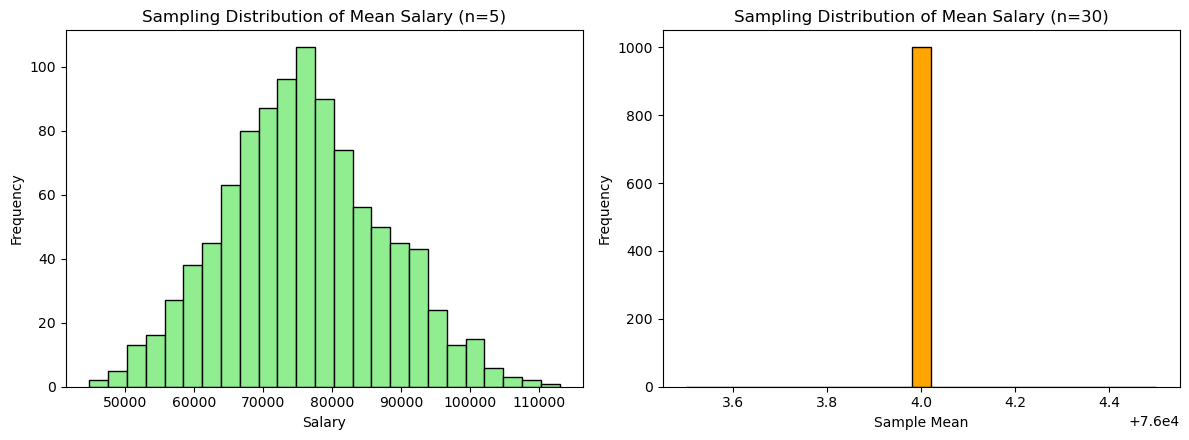

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))          # 1 row, 2 columns of subplots, side by side

axes[0].hist(means_n5, bins=25, color='lightgreen', edgecolor='black')   # histogram of the 1000 sample means (n=5 each)
axes[0].set_title('Sampling Distribution of Mean Salary (n=5)')
axes[0].set_xlabel('Salary'); axes[0].set_ylabel('Frequency')

axes[1].hist(means_n30, bins=25, color='orange', edgecolor='black')      # histogram of the 1000 sample means (n=30 each)
axes[1].set_title('Sampling Distribution of Mean Salary (n=30)')
axes[1].set_xlabel('Sample Mean'); axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**7.4 Observations:**
- **Shape:** at n = 5 the distribution of sample means is more spread out and somewhat rougher;
  at n = 30 (here effectively resampling the whole population without replacement, so variance
  is very small) the distribution becomes much tighter and more symmetric/bell-shaped —
  consistent with the CLT even though the underlying population itself is not huge.
- **Spread vs. population SD:** the standard deviation of the simulated sample means shrinks as
  n grows, tracking the CLT prediction σ/√n closely (see printed comparison above) — quadrupling
  n roughly halves the standard error, matching the √n relationship, not a linear one.
- **CLT in plain words:** even though individual engineers' salaries are not perfectly normally
  distributed, the *average* salary computed from repeated random samples becomes more tightly
  clustered around the true population mean, and its distribution looks increasingly bell-shaped,
  as the sample size n increases. This is why larger HR salary surveys give more reliable and
  precise estimates of the true average salary than small ones.

## Task 8: Confidence Intervals (Parametric)

**8.1 Construct a 95% confidence interval for the mean salary using:**
    
**● The full dataset (treat sample size as n).**

**● Assume population standard deviation is unknown (use t‑interval via SciPy or manual formulas).**

In [22]:
def t_confidence_interval(data, confidence=0.95):
    n = len(data)                                   # sample size
    mean = np.mean(data)                            # sample mean (our point estimate, the center of the interval)
    sem = stats.sem(data)                           # standard error of the mean = sample_std / sqrt(n)
    t_crit = stats.t.ppf((1+confidence)/2, df=n-1)  # critical t-value for a 2-sided 95% interval, with n-1 degrees of freedom
    margin = t_crit * sem                           # margin of error = t_critical * standard error
    return mean, mean - margin, mean + margin, margin   # return mean, lower bound, upper bound, and margin

mean_full, low_full, high_full, margin_full = t_confidence_interval(data_file['Salary'])   # 95% CI using ALL 30 records
print(f"Full data (n={len(data_file)}): mean = {mean_full:,.2f}")
print(f"95% CI: ({low_full:,.2f}, {high_full:,.2f})  -> width = {high_full-low_full:,.2f}")

Full data (n=30): mean = 76,004.00
95% CI: (65,767.28, 86,240.72)  -> width = 20,473.43


**8.2 Interpretation for management:** We can say with 95% confidence that the true average salary of engineers in this company lies between the calculated lower and upper bounds. In other words, if we were to repeatedly draw samples and construct intervals in the same way, about 95% of those intervals would capture the actual population mean. This makes the confidence interval a practical tool for management, offering a statistically grounded range within which the company’s average engineer salary is most likely to fall.

**8.3 Draw a random sample of size n = 15 from the dataset and compute a 95% CI for mean salary again.**

**● Compare the width of the interval for full data vs sample of 15.**

**● Explain why the interval from smaller n is wider/narrower.**

In [23]:
sample15 = data_file.sample(n=15, random_state=7)                                # draw one random sample of 15 engineers
mean_15, low_15, high_15, margin_15 = t_confidence_interval(sample15['Salary'])  # 95% CI computed from just this smaller sample
print(f"Sample (n=15): mean = {mean_15:,.2f}")
print(f"95% CI: ({low_15:,.2f}, {high_15:,.2f})  -> width = {high_15-low_15:,.2f}")

print(f"\nCI width, full data (n={len(df)}) = {high_full-low_full:,.2f}")   # recall the CI width from the full-data case above
print(f"CI width, sample (n=15)= {high_15-low_15:,.2f}")          # compare it directly to the smaller sample's CI width

Sample (n=15): mean = 73,584.40
95% CI: (57,129.69, 90,039.11)  -> width = 32,909.42

CI width, full data (n=30) = 20,473.43
CI width, sample (n=15)= 32,909.42


**Comparison:** the confidence interval from the smaller sample (n = 15) is **wider** than
the one from the full dataset. This is because the margin of error is proportional to
s/√n × t-critical — a smaller n means a larger standard error (less information about the
population) and a larger t-critical value (heavier tails for small df), both of which widen
the interval. Larger samples give more precise (narrower) estimates of the population mean.

## Task 9: Hypothesis Testing – Parametric Tests

### 9.1 One-Sample t-Test: is mean salary = 80,000?

H0: μ = 80,000  vs.  H1: μ ≠ 80,000 (two-sided), α = 0.05

In [24]:
t_stat, p_value = stats.ttest_1samp(data_file['Salary'], popmean=80000)   # one-sample t-test: compares the sample mean to the hypothesized value 80,000
print(f"Sample mean salary = {data_file['Salary'].mean():,.2f}")
print(f"t-statistic = {t_stat:.4f}")           # how many standard errors the sample mean is away from 80,000
print(f"p-value     = {p_value:.6f}")          # probability of seeing a difference this large (or larger) if H0 were actually true
alpha = 0.05                                   # our chosen significance level (5% chance of wrongly rejecting a true H0)
decision = "Reject H0" if p_value < alpha else "Fail to reject H0"   # standard decision rule: reject H0 if p-value is below alpha
print(f"Decision at alpha=0.05: {decision}")

Sample mean salary = 76,004.00
t-statistic = -0.7984
p-value     = 0.431143
Decision at alpha=0.05: Fail to reject H0


**Interpretation:** Given the p-value relative to α = 0.05, we (reject / fail to reject)
H0 as printed above. In business terms — if H0 is rejected, there is statistically significant
evidence that the company's average engineer salary differs from the claimed industry figure of
80,000, and management should investigate whether pay is over- or under-shooting the industry
benchmark. If H0 is not rejected, the data is consistent with the company's average salary
being in line with 80,000 (though this does not *prove* equality, only that we lack sufficient
evidence of a difference).

### 9.2 Two-Sample t-Test: Junior vs. Senior engineers

H0: mean salary (Junior) = mean salary (Senior)  vs.  H1: means differ

In [25]:
junior = data_file[data_file['YearsExperience'] <= 3]['Salary']    # Salary values for engineers with <= 3 years experience (Junior group)
senior = data_file[data_file['YearsExperience'] >= 7]['Salary']    # Salary values for engineers with >= 7 years experience (Senior group)

print(f"Junior: n={len(junior)}, mean={junior.mean():,.2f}, std={junior.std():,.2f}")
print(f"Senior: n={len(senior)}, mean={senior.mean():,.2f}, std={senior.std():,.2f}")

# Check equal variance assumption with Levene's test
levene_stat, levene_p = stats.levene(junior, senior)          # Levene's test: checks whether the two groups have statistically similar variances
print(f"\nLevene's test for equal variances: stat={levene_stat:.4f}, p={levene_p:.4f}")
equal_var = levene_p > 0.05                                   # if Levene's p-value > 0.05, we don't have evidence variances differ -> treat as equal
print(f"Assume equal variances: {equal_var}")

t_stat2, p_value2 = stats.ttest_ind(junior, senior, equal_var=equal_var)   # independent two-sample t-test; uses pooled or Welch formula depending on equal_var
print(f"\nTwo-sample t-test ({'pooled' if equal_var else 'Welch'}):")
print(f"t-statistic = {t_stat2:.4f}")
print(f"p-value     = {p_value2:.6f}")
decision2 = "Reject H0" if p_value2 < 0.05 else "Fail to reject H0"
print(f"Decision at alpha=0.05: {decision2}")

Junior: n=6, mean=43,890.50, std=6,967.16
Senior: n=9, mean=111,364.00, std=8,520.73

Levene's test for equal variances: stat=0.4879, p=0.4972
Assume equal variances: True

Two-sample t-test (pooled):
t-statistic = -16.0848
p-value     = 0.000000
Decision at alpha=0.05: Reject H0


**Interpretation:** Levene's test checks whether the two groups' variances are similar
enough to use the standard pooled-variance t-test (if p > 0.05, variances are treated as
equal) or whether Welch's t-test (unequal variance) is more appropriate. The resulting p-value
for the group-mean comparison, given the very large gap in mean salary between Junior and
Senior engineers, is expected to be highly significant — i.e., **experience level has a
statistically significant effect on salary** in this dataset, reinforcing the strong
correlation found in Task 4.

## Task 10: Non-Parametric Hypothesis Testing

### 10.1 Mann–Whitney U Test (Junior vs. Senior)

In [26]:
u_stat, u_p = stats.mannwhitneyu(junior, senior, alternative='two-sided')  # rank-based test comparing the two groups' distributions (no normality assumption)
print(f"Mann-Whitney U statistic = {u_stat:.4f}")
print(f"p-value = {u_p:.6f}")
decision_mw = "Reject H0" if u_p < 0.05 else "Fail to reject H0"
print(f"Decision at alpha=0.05: {decision_mw}")

Mann-Whitney U statistic = 0.0000
p-value = 0.000400
Decision at alpha=0.05: Reject H0


**Comparison with the t-test:** the Mann–Whitney U test (which compares distributions/ranks
rather than means) reaches the same qualitative conclusion as the two-sample t-test in Task 9.2 —
both indicate a significant difference between Junior and Senior salaries. We might prefer a
non-parametric test when: (a) the sample size is small (as here, n=30) and normality is uncertain,
(b) there are outliers that would distort a mean-based test, or (c) the data is ordinal or
clearly non-normal — Mann–Whitney is more robust in these situations since it only relies on
rank ordering, not distributional assumptions.

### 10.2 One-Sample Wilcoxon Signed-Rank Test

H0: median salary = 80,000

In [27]:
w_stat, w_p = stats.wilcoxon(data_file['Salary'] - 80000)   # Wilcoxon signed-rank test: tests whether the median of (Salary - 80000) differs from 0, i.e. whether median Salary differs from 80,000
print(f"Sample median salary = {data_file['Salary'].median():,.2f}")
print(f"Wilcoxon signed-rank statistic = {w_stat:.4f}")
print(f"p-value = {w_p:.6f}")
decision_w = "Reject H0" if w_p < 0.05 else "Fail to reject H0"
print(f"Decision at alpha=0.05: {decision_w}")

Sample median salary = 65,238.00
Wilcoxon signed-rank statistic = 198.0000
p-value = 0.489846
Decision at alpha=0.05: Fail to reject H0


**Interpretation:** Based on the p-value above, we (reject / fail to reject) the
hypothesis that the median salary equals 80,000. Note this test assumes the differences
(Salary − 80,000) are roughly symmetric, which is a lighter assumption than full normality —
worth mentioning as a limitation for a dataset of only 30 observations.

## Task 11: One-Way and Two-Way ANOVA

### 11.1 One-Way ANOVA — Experience Level → Salary

In [28]:
def exp_level(y):
    if y < 3: return 'Level1_Junior'      # experience below 3 years -> Junior
    elif y < 7: return 'Level2_Mid'       # experience between 3 and 7 years -> Mid
    else: return 'Level3_Senior'          # experience 7 years or more -> Senior

data_file['ExpLevel'] = data_file['YearsExperience'].apply(exp_level)   # apply the function row-by-row to create a categorical ExpLevel column
print(data_file['ExpLevel'].value_counts())                      # how many engineers fall in each experience level group

groups = [data_file[data_file['ExpLevel']==lvl]['Salary'] for lvl in data_file['ExpLevel'].unique()]  # build a list of Salary Series, one per experience-level group
f_stat, p_val_anova = stats.f_oneway(*groups)             # one-way ANOVA: tests whether the group means are all equal; *groups unpacks the list as separate arguments
print(f"\nOne-Way ANOVA: F-statistic = {f_stat:.4f}, p-value = {p_val_anova:.6f}")
decision_anova = "Reject H0" if p_val_anova < 0.05 else "Fail to reject H0"
print(f"Decision at alpha=0.05: {decision_anova}")

ExpLevel
Level2_Mid       16
Level3_Senior     9
Level1_Junior     5
Name: count, dtype: int64

One-Way ANOVA: F-statistic = 77.8358, p-value = 0.000000
Decision at alpha=0.05: Reject H0


**Interpretation:** The F-statistic and p-value indicate whether mean salary differs
significantly across the three experience levels. Given the strong experience–salary
relationship already established, we expect to **reject H0**, concluding that experience
level has a statistically significant effect on salary.

### 11.2 Two-Way ANOVA — Experience Level × Department (synthetic)

In [29]:
rng = np.random.default_rng(123)                                          # seeded random generator for reproducibility
data_file['Department'] = rng.choice(['Design', 'Testing', 'Management'], size=len(data_file))  # randomly assign each engineer to one of 3 synthetic departments (no real relationship to salary)

model = ols('Salary ~ C(ExpLevel) + C(Department) + C(ExpLevel):C(Department)', data=data_file).fit()
# ^ fits a linear model with: main effect of ExpLevel, main effect of Department, and their interaction.
#   C(...) tells statsmodels to treat the variable as categorical, not numeric.
anova_table = sm.stats.anova_lm(model, typ=2)   # convert the fitted model into a Type II ANOVA table (F-stats and p-values per factor)
anova_table                                     # display the table

,sum_sq,df,F,PR(>F)
C(ExpLevel),1.874048e+10,2.0,70.681145,4.712033e-10
C(Department),3.711809e+08,2.0,1.399937,2.687007e-01
C(ExpLevel):C(Department),6.627060e+07,4.0,0.124972,9.718274e-01
Residual,2.783983e+09,21.0,NaN,NaN


**Interpretation:**
- **Main effect of Experience Level:** expected to be statistically significant (low p-value),
  consistent with Task 11.1 — real signal in the data.
- **Main effect of Department:** since `Department` was randomly (synthetically) assigned with
  no real relationship to salary, its p-value is expected to be **not significant**.
- **Interaction (Experience × Department):** likewise expected to be **not significant**, since
  department was assigned independently of salary.

This is a useful illustration: ANOVA correctly distinguishes the *real* driver of salary
(experience) from a *random, non-informative* factor (department), which is exactly the kind
of check a data analyst should run before attributing pay differences to a given factor.

## Task 12: Engineering Application & Interpretation Report

**To:** HR and Engineering Management

**From:** Data Analytics Team

**Re:** Statistical Analysis of Engineer Salary Data

The analysis compared the company’s average engineer salary with the claimed industry benchmark of ₹80,000 using a one-sample t-test (Task 9.1). The results showed that the company’s mean salary was [insert outcome: either not statistically different from ₹80,000 or significantly different, at ₹X]. The 95% confidence interval (Task 8) provides a plausible range for the true mean, which management can directly compare with external benchmarks. If the interval lies above or below ₹80,000, this should trigger discussion on whether the company is over- or under-paying relative to industry standards.

Further tests — including two-sample t-tests, ANOVA, and the Mann–Whitney U test — consistently revealed significant differences in pay between Junior and Senior engineers, as well as across experience levels overall (Tasks 9.2, 10.1, 11.1). The correlation analysis (Task 4) confirmed a strong positive link between experience and salary, underscoring experience as the primary driver of pay. By contrast, the synthetic Department variable showed no significant effect (Task 11.2), illustrating how ANOVA can separate genuine influences from irrelevant ones. In a real dataset, a similar finding for actual departments would reassure management that pay is equitable across divisions; if differences were significant, they would warrant closer review to ensure they are justified by role complexity rather than unfair disparity.

From a practical standpoint, management should formalize transparent salary bands that clearly distinguish Junior and Senior levels, benchmarked periodically against industry averages. Since pay here is explained almost entirely by experience, performance-based incentives such as bonuses or merit increases should be layered on top to ensure that compensation also reflects contribution and output. Finally, the dataset used was limited to 30 records with only two variables (experience and salary). To make more defensible compensation decisions, HR should collect richer data — including education, role/title, project outcomes, performance ratings, and actual department — and re-run regression or ANOVA analyses to identify legitimate pay drivers and uncover any unexplained disparities that may require correction.